In [1]:
import matplotlib.pyplot as plt
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.layers.embeddings import GridEmbedding2D

# Data load

In [2]:
# 데이터 로드
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=20,
    batch_size=4,
    test_resolutions=[16, 32],
    n_tests=[10, 10],
    test_batch_sizes=[4, 2],
)


train_dataset = train_loader.dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 


In [3]:
# 데이터 위치 찾기
import inspect
from neuralop.data.datasets import load_darcy_flow_small
print(inspect.getsourcefile(load_darcy_flow_small))

/home/seongwon/anaconda3/lib/python3.13/site-packages/neuralop/data/datasets/darcy.py


In [4]:
for res, test_loader in test_loaders.items():
    print(f"Resolution: {res}")
    # Get first batch
    batch = next(iter(test_loader))
    x = batch["x"]  # Input
    y = batch["y"]  # Output

    print(f"Testing samples for resolution {res} have shape {x.shape[1:]}")

data = train_dataset[0]
x = data["x"]
y = data["y"]
print(f"Training samples have shape {x.shape[1:]}")

# Which sample to view
index = 0

data = train_dataset[index]
data = data_processor.preprocess(data, batched=False) # Preprocess the data 그냥 normalize

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1) #객체를 생성.
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0) #GridEmbedding2D는 입력에 배치 차원이 필요하므로 unsqueeze(0)으로 배치 차원을 추가한 후, 출력에서 다시 제거하기 위해 squeeze(0)을 사용
y = data["y"]

Resolution: 16
Testing samples for resolution 16 have shape torch.Size([1, 16, 16])
Resolution: 32
Testing samples for resolution 32 have shape torch.Size([1, 32, 32])
Training samples have shape torch.Size([16, 16])


In [5]:
print(positional_embedding(data["x"].unsqueeze(0)).shape)  # Should be [channels, height, width]
print(positional_embedding(data["x"].unsqueeze(0)).squeeze(0).shape)  # Should be [channels, height, width]

torch.Size([1, 3, 16, 16])
torch.Size([3, 16, 16])


/tmp/ipykernel_8961/1620830071.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


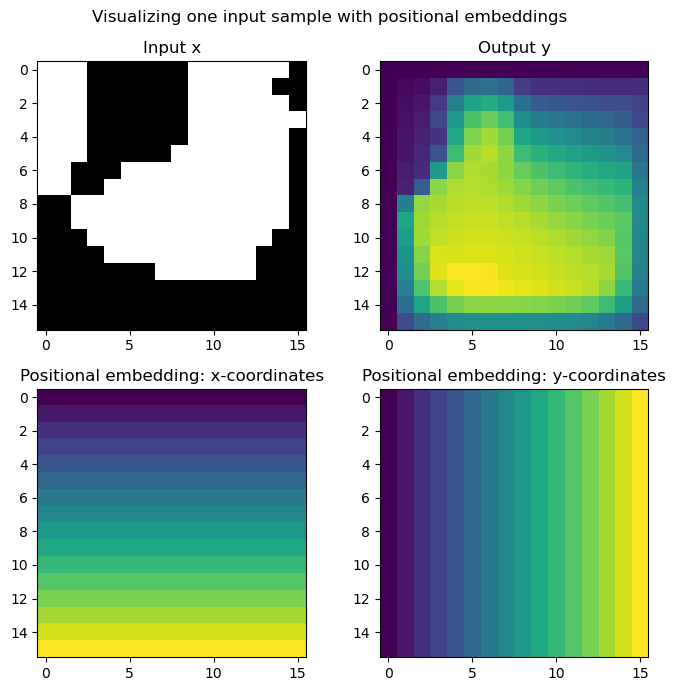

In [6]:
# 데이터 시각화
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()

# FNO Learning

In [7]:
import torch
import matplotlib.pyplot as plt
import sys
from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.utils import count_model_params
from neuralop import LpLoss, H1Loss
import numpy as np

device = "cuda"

In [8]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=1000,
    batch_size=64,
    n_tests=[100, 50],
    test_resolutions=[16, 32],
    test_batch_sizes=[32, 32],
)

data_processor = data_processor.to(device)

Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 


In [9]:
# 모델 초기화
model = FNO(
    n_modes=(8,8),
    in_channels=1,
    out_channels=1,
    hidden_channels=24,
    projection_channel_ratio=2,
)
model = model.to(device)

# Count and display the number of parameters
n_params = count_model_params(model) # 모델의 파라미터 수를 계산
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush() # 버퍼에 있는 내용을 강제로 출력하게 하는 함수임.


Our model has 191881 parameters.


In [10]:
# creating the optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=1e-2, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30) # CosineAnnealingLR는 학습률을 코사인 함수 형태로 조정하는 스케줄러입니다. T_max는 한 사이클의 길이를 나타냄 여기서는 30 에폭마다 학습률이 초기값으로 돌아오도록 설정되어 있음

In [11]:
# Setting up loss functions

l2loss = LpLoss(d=2, p=2) # L2 loss for function values
h1loss = H1Loss(d=2)  # H1 loss includes gradient information

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}

In [12]:
print("\n### MODEL ###\n", model)
print("\n### OPTIMIZER ###\n", optimizer)
print("\n### SCHEDULER ###\n", scheduler)
print("\n### LOSSES ###")
print(f"\n * Train: {train_loss}")
print(f"\n * Test: {eval_losses}")
sys.stdout.flush()


### MODEL ###
 FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([24, 24, 8, 5]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(24, 24, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(24, 12, kernel_size=(1,), stride=(1,))
          (1): Conv1d(12, 24, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(3, 48, kernel_size=(1,), stride=(1,))
      (1): Conv1d(48, 24, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(24, 48, kernel_size=(1,), stride=(1,))
      (1): Conv1d(48, 1

In [13]:
# Creating the trainer
trainer = Trainer(
    model=model,
    n_epochs=15,
    device=device,
    data_processor=data_processor,
    wandb_log=False,  # Disable Weights & Biases logging for this tutorial
    eval_interval=5,  # Evaluate every 5 epochs
    use_distributed=False,  # Single GPU/CPU training
    verbose=True,  # Print training progress
)


trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    eval_losses=eval_losses,
)

Training on 1000 samples
Testing on [50, 50] samples         on resolutions [16, 32].


/home/seongwon/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1787: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([64, 1, 16, 16])


/home/seongwon/anaconda3/lib/python3.13/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=1.09, avg_loss=0.7605, train_err=47.5281


/home/seongwon/anaconda3/lib/python3.13/site-packages/neuralop/training/trainer.py:581: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  val_loss = loss(out, **sample)


Eval: 16_h1=0.5800, 16_l2=0.3937, 32_h1=0.6866, 32_l2=0.3898
[5] time=0.43, avg_loss=0.2585, train_err=16.1582
Eval: 16_h1=0.2593, 16_l2=0.1737, 32_h1=0.3751, 32_l2=0.1852
[10] time=0.50, avg_loss=0.1997, train_err=12.4835
Eval: 16_h1=0.2077, 16_l2=0.1320, 32_h1=0.3408, 32_l2=0.1507


{'train_err': 11.112787902355194,
 'avg_loss': 0.17780460643768312,
 'avg_lasso_loss': None,
 'epoch_train_time': 0.4131558280205354}

/tmp/ipykernel_8961/3315996855.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


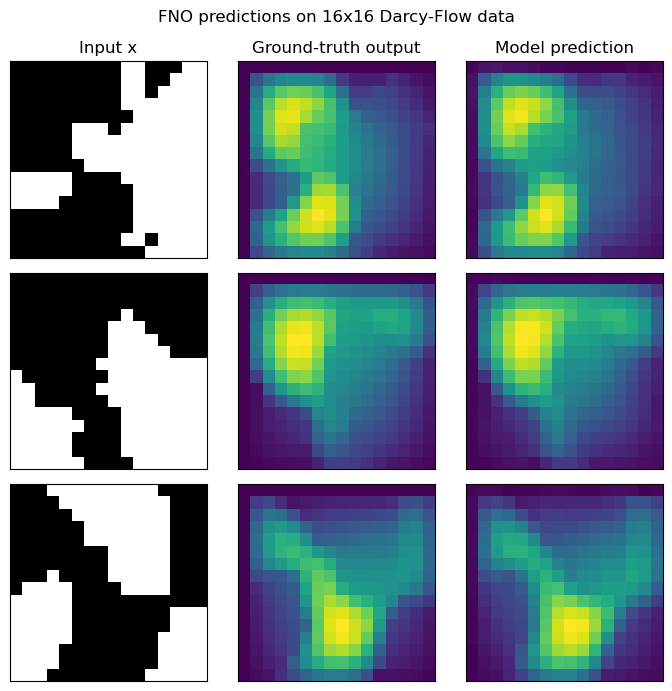

In [14]:
test_samples = test_loaders[16].dataset

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    data = test_samples[index]
    data = data_processor.preprocess(data, batched=False)

    # Input
    x = data["x"]
    # Ground-truth output
    y = data["y"]
    # Model prediction
    out = model(x.unsqueeze(0))

    # Plot input
    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x.cpu()[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot ground-truth output
    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.cpu().squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot model prediction
    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.cpu().squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("FNO predictions on 16x16 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()

In [15]:
print(f"test_loaders[16] dataset size: {len(test_loaders[16].dataset)}")                                                   
print(f"test_loaders[32] dataset size: {len(test_loaders[32].dataset)}")  

test_loaders[16] dataset size: 50
test_loaders[32] dataset size: 50


In [16]:
# 결과 데이터와 모델의 차이
test_data = test_loaders[16].dataset 
rel_l2_list = []

for i in range(50):
    data = test_data[i]
    data = data_processor.preprocess(data, batched=False)

    # Input
    x_16 = data["x"]
    y_16 = data["y"]
    out = model(x_16.unsqueeze(0))
    rel_l2 = torch.norm(y_16 - out) / torch.norm(y_16)
    rel_l2_list.append(rel_l2.item())

rel_l2_16 = np.mean(rel_l2_list)
    
print(f"Relative L2 Error: {rel_l2_16:.4f}")

Relative L2 Error: 0.1883


/tmp/ipykernel_8961/364703059.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


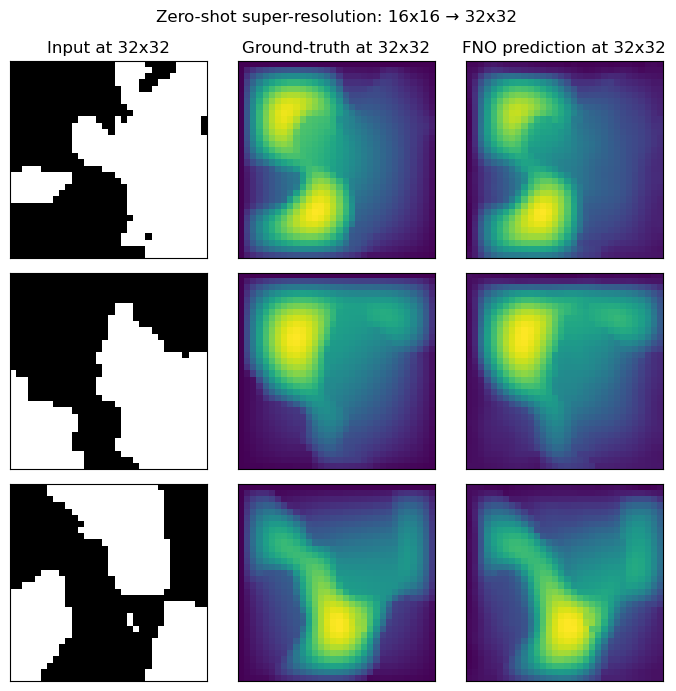

In [17]:
test_samples = test_loaders[32].dataset

fig = plt.figure(figsize=(7, 7))
for index in range(3):
    data = test_samples[index]
    data = data_processor.preprocess(data, batched=False)

    # Input at higher-resolution
    x = data["x"]
    # Ground-truth output at higher-resolution
    y = data["y"]
    # Model prediction at higher-resolution
    out = model(x.unsqueeze(0))

    # Plot input at higher-resolution
    ax = fig.add_subplot(3, 3, index * 3 + 1)
    ax.imshow(x.cpu()[0], cmap="gray")
    if index == 0:
        ax.set_title("Input at 32x32")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot ground-truth output at higher-resolution
    ax = fig.add_subplot(3, 3, index * 3 + 2)
    ax.imshow(y.cpu().squeeze())
    if index == 0:
        ax.set_title("Ground-truth at 32x32")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot model prediction at higher-resolution
    ax = fig.add_subplot(3, 3, index * 3 + 3)
    ax.imshow(out.cpu().squeeze().detach().numpy())
    if index == 0:
        ax.set_title("FNO prediction at 32x32")
    plt.xticks([], [])
    plt.yticks([], [])

fig.suptitle("Zero-shot super-resolution: 16x16 → 32x32", y=0.98)
plt.tight_layout()
fig.show()

In [18]:
# 결과 데이터와 모델의 차이
test_data = test_loaders[32].dataset 
rel_l2_list = []

for i in range(50):
    data = test_data[i]
    data = data_processor.preprocess(data, batched=False)

    # Input
    x = data["x"]
    y = data["y"]
    out = model(x.unsqueeze(0))
    rel_l2 = torch.norm(y - out) / torch.norm(y)
    rel_l2_list.append(rel_l2.item())

rel_l2_32 = np.mean(rel_l2_list)
    
print(f"Relative L2 Error: {rel_l2_32:.4f}")

Relative L2 Error: 0.2261


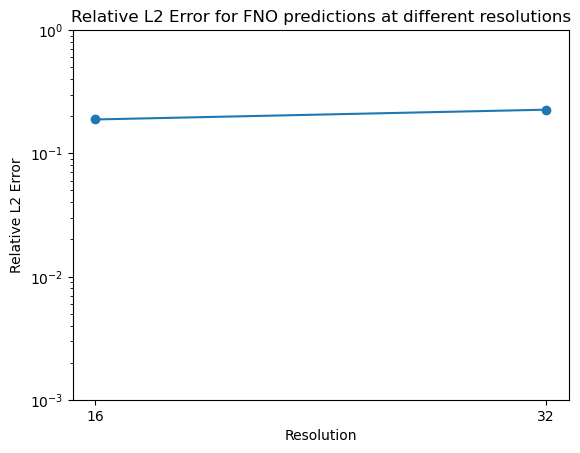

In [19]:
res = [16,32]
rel = [rel_l2_16, rel_l2_32]
plt.plot(res, rel)
plt.scatter(res, rel)
plt.xlabel("Resolution")
plt.ylabel("Relative L2 Error")
plt.title("Relative L2 Error for FNO predictions at different resolutions")
plt.yscale("log")
plt.ylim([1e-3, 1])
plt.xticks(res)
plt.show()

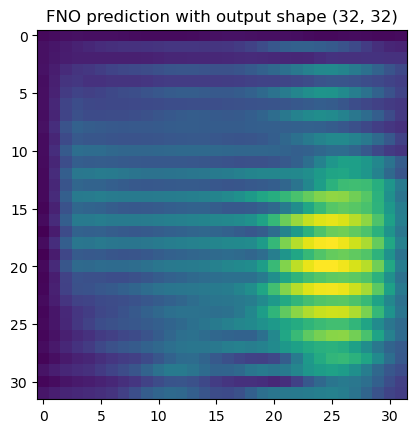

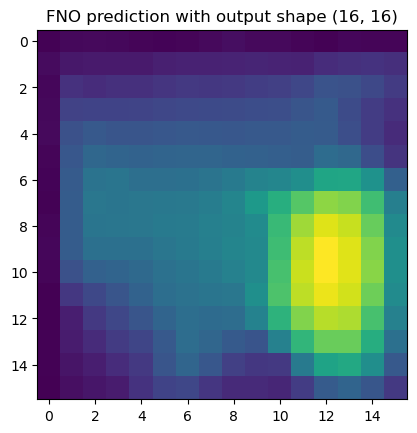

In [20]:
# fr16to32, fr16to16 시각화
fr16to32 = model(x_16.unsqueeze(0), output_shape=(32, 32)).squeeze(0)
plt.imshow(fr16to32[0].detach().cpu().numpy())
plt.title("FNO prediction with output shape (32, 32)")
plt.show()
fr16to16 = model(x_16.unsqueeze(0)).squeeze(0)
plt.imshow(fr16to16[0].detach().cpu().numpy())
plt.title("FNO prediction with output shape (16, 16)")
plt.show()
